In [20]:
#declaring the necesary librarys
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

In [21]:
#we upload the data .txt
data = np.loadtxt('Higgsdata.txt')

Part 1 of 7: First we import the file Higgsdata.txt into a variable so we can work with the contents.  

afterwards we convert the units of the invariant mass from TeV to GeV (We multiply TeV by 1000 because 1 TeV = 10³ GeV.). 

Now we have to make a plot of the resulting data, we make sure that the dots are not shown like a line because this values are all experimental. We also have to establish the correct labels and legend

In [22]:
#first colum refers to TeV, extracting
mass_TeV = data[:, 0]

#second Column for Events, extracting
events = data[:, 1]

#mass transforming from TeV to GeV
mass_GeV = mass_TeV * 1000

To make the plot following the assignment instructions we have to: 

 - Use axis Labels and legend
 - Use the function Scatter() to plot the individual dots without connecting them
 - Use figsize to make the plot clearer

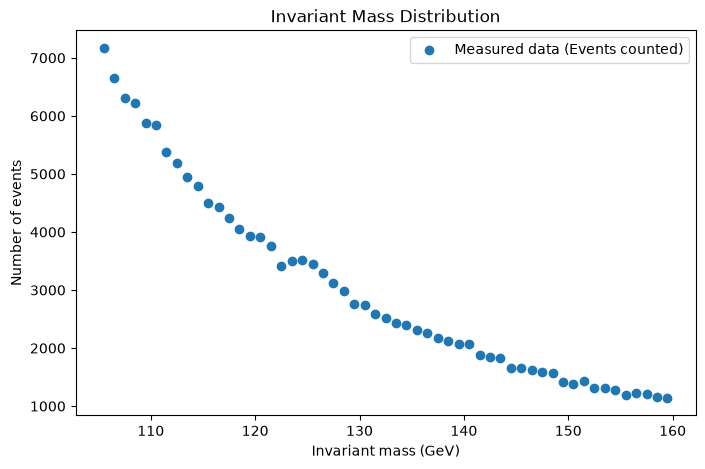

In [23]:
#creating the figure and setting the size
plt.figure(figsize=(8, 5))
plt.scatter(mass_GeV, events, label="Measured data (Events counted)")

#labels and title as requested
plt.xlabel("Invariant mass (GeV)")
plt.ylabel("Number of events")
plt.title("Invariant Mass Distribution")

#plotting
plt.legend()
plt.show()

Part 2 of 7: Now we have to fit a 3rd order polynomial backround. 

In essence, we have to estimate the ordinary backround processes. This means that we have to fit the 3rd order polynomial to the given data, representing the fitted background.

Since we're allowed to use np.polyfit and np.polyval functions, we'll use them to calculate the coefficients and evaluate them to store the background values.

In [24]:
#using polyfit for the coefficents of the 3rd order polynomial
coefficients = np.polyfit(mass_GeV, events, 3)

#evaluating them with polyval for the backround values
background = np.polyval(coefficients, mass_GeV)

Part 3 of 7: Plotting the data to the fitted background

We already plotted on the previous exercise, but now we have an issue; the backround is a mathematical function, which means we have to plot it as a continuous line but keep the measured data as it was (unconnected)

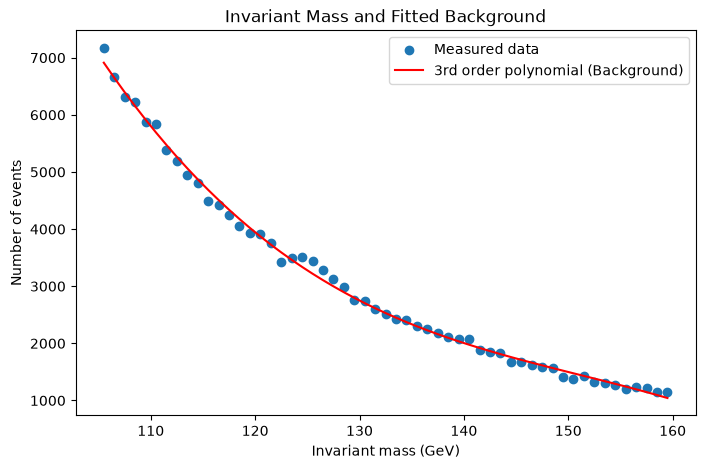

In [25]:
#Plotting, same as first exercise
plt.figure(figsize=(8, 5))

#keeping dotted data
plt.scatter(mass_GeV, events, label="Measured data")

#new fitted background as a function
plt.plot(mass_GeV, background, color='red', label="3rd order polynomial (Background)")

plt.xlabel("Invariant mass (GeV)")
plt.ylabel("Number of events")
plt.title("Invariant Mass and Fitted Background")

plt.legend()
plt.show()

Part 4 of 7: Substracting the backround to get the Signal and plot it

To substract the signal from the background processes, we need to also substract the fitted background values from our original measured data.

Then we will plot it, applying the same logic as the previous plots

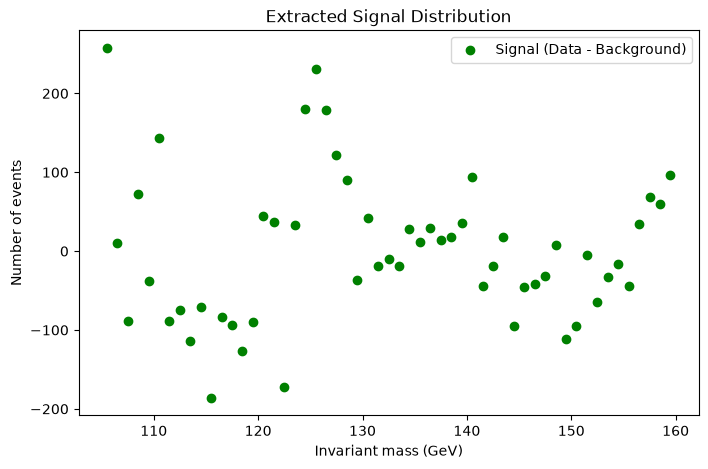

In [26]:
#obtaining the signal by substracting the background from the measured events
signal = events - background

#Plotting as usual
plt.figure(figsize=(8, 5))

plt.scatter(mass_GeV, signal, color='green', label="Signal (Data - Background)")

plt.xlabel("Invariant mass (GeV)")
plt.ylabel("Number of events")
plt.title("Extracted Signal Distribution")

plt.legend()
plt.show()

Part 5 of 7: Fitting a Gaussian Function to the signal

As explained on the assignment document, to characterize the Higgs boson signal it has to be fitted on a Gaussian function such as: 
$$f(x) = a \cdot e^{-\frac{(x-m)^2}{2\sigma^2}}$$

- a: amplitude
- $m$: mean of the signal
- $\sigma$: standrat deviation

we're going to use scipy.optimize.curve fit as mentioned on the pdf. As mentioned we have to use aproppiate values such as an amplitude around 200, a center $m$ around 125 GeV, and a small width 

In [27]:
#gaussian function definition
def gaussian(x, a, m, sigma):
    return a * np.exp(- (x - m)**2 / (2 * sigma**2))

#initial intended-apropiate values
p0 = [200, 125, 2]

#fitting the curve with the extracted signal and the function
popt, pcov = curve_fit(gaussian, mass_GeV, signal, p0=p0)

# Extract the optimal parameters
a_opt, m_opt, sigma_opt = popt

#checking if the result makes sense
print("Optimal parameters found:")
print(f"Amplitude (a): {a_opt}")
print(f"Center (m): {m_opt} GeV")
print(f"Sigma (sigma): {sigma_opt}")

Optimal parameters found:
Amplitude (a): 237.1690716668551
Center (m): 125.88393026701544 GeV
Sigma (sigma): 1.3235650579423257


the found parameters make sense for these reasons: 

- Center (m): 125.88393026701544 GeV -> it matches the mass of the Higgs boson and reflects the observed peak of the signal
- Amplitude (a): 237.1690716668551 -> it represents the maximum height of the excess events peak (200-250 events)
- Sigma (sigma): 1.3235650579423257 -> we expected a narrow width as expected for the detector mass resolution

Part 6 of 7: Plotting the signal and the Gaussian fit

To make sure the fitting goes well, we have to plot the extracted signal like dots and the Gaussian fit as a continuous line. 

What value does the parameter m have?
- As we mentioned on the previous exercise, the value of the center was 125.88393026701544 GeV, which is very close to the actual accepted mass of the Higgs boson (125 GeV)

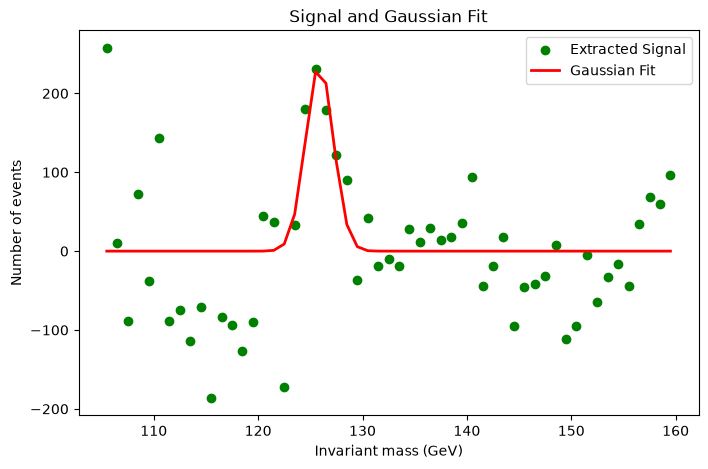

In [28]:
#plotting the data
plt.figure(figsize=(8, 5))

plt.scatter(mass_GeV, signal, color='green', label="Extracted Signal")

#calling the gaussian function with the parameters found on the 5th exercise
plt.plot(mass_GeV, gaussian(mass_GeV, a_opt, m_opt, sigma_opt), color='red', linewidth=2, label="Gaussian Fit")

plt.xlabel("Invariant mass (GeV)")
plt.ylabel("Number of events")
plt.title("Signal and Gaussian Fit")

plt.legend()
plt.show()

Part 7 of 7: Total fit and plotting

The objective of this last exercise is to combine all the previous work on a plot. the fitted background (the 3rd order polynomial) and the fitted signal (the Gaussian curve)

Besides the provided data i'll stick to the one obtained on the 5th execise since our fit already converged perfectly with our own initial guesses.

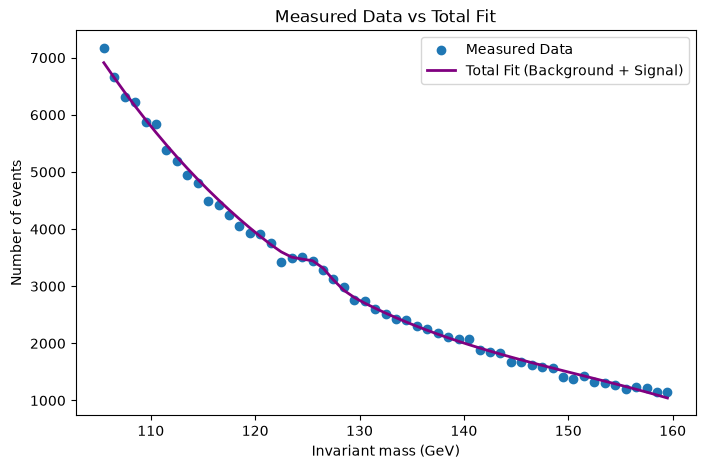

In [29]:
#evaluating the gaussian with the parameters and obtaining the total fit
fitted_signal = gaussian(mass_GeV, a_opt, m_opt, sigma_opt)
total_fit = background + fitted_signal

#plotting as usual with the total fit
plt.figure(figsize=(8, 5))

plt.scatter(mass_GeV, events, label="Measured Data")

plt.plot(mass_GeV, total_fit, color='purple', linewidth=2, label="Total Fit (Background + Signal)")

plt.xlabel("Invariant mass (GeV)")
plt.ylabel("Number of events")
plt.title("Measured Data vs Total Fit")

plt.legend()
plt.show()